# Cas de tests officiels — validation de la bibliothèque C++ `ML_ESGI`

**Auteur : Maxime Clément** (partie individuelle : cas de tests, interfaçage Python).

Ce notebook reprend la **batterie officielle de cas de tests du cours** (« Cas de tests, rendu 2 »)
et l'exécute sur **nos implémentations C++** (Modèle Linéaire, MLP, SVM, RBF) manipulées depuis
Python via la bibliothèque dynamique `ML_ESGI` (pybind11) — comme l'exige le syllabus :
*« il sera impératif de démontrer la justesse de l'implémentation de ces derniers sur les cas de tests proposés »*.

Pour chaque cas, l'annotation du cours est rappelée :
- **OK** : le modèle doit réussir.
- **KO** : l'échec est **attendu** (limite théorique du modèle — c'est la démonstration qui compte).

> Note reproductibilité : les datasets aléatoires sont générés avec une graine fixe (`np.random.seed`).
> Le MLP, lui, part de poids aléatoires non déterministes : quand le SGD peut tomber dans un
> minimum local (XOR, Cross…), on relance l'entraînement quelques fois et on garde le meilleur run.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

# La lib compilée ML_ESGI.pyd et training_utils.py sont dans scripts/
ROOT = os.path.abspath(os.getcwd())
sys.path.insert(0, os.path.join(ROOT, "scripts"))

import training_utils
training_utils.enable_cpp_dlls()   # DLLs du runtime C++ — à faire AVANT l'import
import ML_ESGI

print("Bibliothèque C++ chargée :", ML_ESGI.__file__)

Bibliothèque C++ chargée : /Users/yum/Documents/Me/2025-2026 – ESGI/Projet annuel /ML_from_scratch/scripts/ML_ESGI.cpython-39-darwin.so


## Fonctions utilitaires (affichage des frontières de décision et des régressions)

Les modèles C++ prédisent point par point ; on échantillonne le plan sur une grille
et on colore chaque zone selon la classe prédite → la **frontière de décision** apparaît.

In [2]:
# ---------- Classification binaire (labels -1 / +1) ----------

def accuracy_binaire(predict, X, Y):
    """Proportion d'exemples bien classés (labels -1/+1)."""
    preds = [predict(x) for x in X.tolist()]
    return float(np.mean([p == y for p, y in zip(preds, Y)]))

def plot_frontiere_2c(ax, predict, X, Y, titre):
    """Fond coloré = classe prédite par le modèle en chaque point du plan."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 150), np.linspace(y_min, y_max, 150))
    Z = np.array([predict(p) for p in np.c_[xx.ravel(), yy.ravel()].tolist()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-2, 0, 2], colors=["#ffd6d6", "#d6e8ff"])
    ax.scatter(X[Y == 1][:, 0], X[Y == 1][:, 1], c="#0055cc", edgecolors="k", label="+1", zorder=3)
    ax.scatter(X[Y == -1][:, 0], X[Y == -1][:, 1], c="#cc0000", edgecolors="k", label="-1", zorder=3)
    ax.set_title(titre, fontsize=10)

def show_cas_2classes(X, Y, modeles, cas):
    """modeles : liste de (nom, attendu 'OK'/'KO', fonction predict(x) -> ±1)."""
    fig, axes = plt.subplots(1, len(modeles), figsize=(4.5 * len(modeles), 4))
    axes = np.atleast_1d(axes)
    for ax, (nom, attendu, predict) in zip(axes, modeles):
        acc = accuracy_binaire(predict, X, Y)
        plot_frontiere_2c(ax, predict, X, Y, f"{nom}\nacc = {acc:.0%} (attendu : {attendu})")
        print(f"  {cas} | {nom:<28} acc = {acc:>4.0%}   (attendu : {attendu})")
    fig.suptitle(cas)
    plt.tight_layout(); plt.show()


# ---------- Classification multi-classes (labels one-hot -1 / +1) ----------

FONDS  = ["#ffd6d6", "#d6e8ff", "#d9f2d9"]
POINTS = ["#cc0000", "#0055cc", "#00882f"]

def accuracy_multi(predict_idx, X, Y_onehot):
    preds = np.array([predict_idx(x) for x in X.tolist()])
    return float(np.mean(preds == Y_onehot.argmax(axis=1)))

def show_cas_multiclasses(X, Y_onehot, modeles, cas):
    """modeles : liste de (nom, attendu, fonction predict(x) -> index de classe)."""
    fig, axes = plt.subplots(1, len(modeles), figsize=(4.5 * len(modeles), 4))
    axes = np.atleast_1d(axes)
    vraies = Y_onehot.argmax(axis=1)
    for ax, (nom, attendu, predict_idx) in zip(axes, modeles):
        x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
        y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 150), np.linspace(y_min, y_max, 150))
        Z = np.array([predict_idx(p) for p in np.c_[xx.ravel(), yy.ravel()].tolist()]).reshape(xx.shape)
        ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5, 2.5], colors=FONDS)
        for k in range(Y_onehot.shape[1]):
            pts = X[vraies == k]
            ax.scatter(pts[:, 0], pts[:, 1], c=POINTS[k], edgecolors="k", s=18, zorder=3)
        acc = accuracy_multi(predict_idx, X, Y_onehot)
        ax.set_title(f"{nom}\nacc = {acc:.0%} (attendu : {attendu})", fontsize=10)
        print(f"  {cas} | {nom:<28} acc = {acc:>4.0%}   (attendu : {attendu})")
    fig.suptitle(cas)
    plt.tight_layout(); plt.show()


# ---------- Régression ----------

def mse(predict, X, Y):
    return float(np.mean([(predict(x) - y) ** 2 for x, y in zip(X.tolist(), Y)]))

def show_regression_1d(X, Y, modeles, cas):
    """Entrée 1D : courbe prédite + points d'apprentissage."""
    xs = np.linspace(X.min() - 0.5, X.max() + 0.5, 200)
    fig, axes = plt.subplots(1, len(modeles), figsize=(4.5 * len(modeles), 4))
    axes = np.atleast_1d(axes)
    for ax, (nom, attendu, predict) in zip(axes, modeles):
        ax.plot(xs, [predict([v]) for v in xs], "b-", label="modèle")
        ax.scatter(X[:, 0], Y, c="k", s=60, zorder=3, label="exemples")
        m = mse(predict, X, Y)
        ax.set_title(f"{nom}\nMSE = {m:.4f} (attendu : {attendu})", fontsize=10)
        ax.legend()
        print(f"  {cas} | {nom:<28} MSE = {m:.4f}   (attendu : {attendu})")
    fig.suptitle(cas)
    plt.tight_layout(); plt.show()

def show_regression_2d(X, Y, modeles, cas):
    """Entrée 2D : surface prédite (3D) + points d'apprentissage."""
    fig = plt.figure(figsize=(4.8 * len(modeles), 4.2))
    for i, (nom, attendu, predict) in enumerate(modeles):
        ax = fig.add_subplot(1, len(modeles), i + 1, projection="3d")
        gx, gy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 25),
                             np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 25))
        gz = np.array([predict([a, b]) for a, b in zip(gx.ravel(), gy.ravel())]).reshape(gx.shape)
        ax.plot_surface(gx, gy, gz, alpha=0.45, cmap="coolwarm")
        ax.scatter(X[:, 0], X[:, 1], Y, c="k", s=50)
        m = mse(predict, X, Y)
        ax.set_title(f"{nom}\nMSE = {m:.4f} (attendu : {attendu})", fontsize=10)
        print(f"  {cas} | {nom:<28} MSE = {m:.4f}   (attendu : {attendu})")
    fig.suptitle(cas)
    plt.tight_layout(); plt.show()


# ---------- Entraînement ----------

def entrainer_lineaire_ovr(X, Y_onehot, lr, epochs):
    """Un perceptron binaire par classe (One-vs-Rest) ; prédiction = argmax des scores bruts."""
    modeles = []
    for k in range(Y_onehot.shape[1]):
        m = ML_ESGI.LinearModel(X.shape[1], is_classification=True)
        m.train(X.flatten().tolist(), Y_onehot[:, k].astype(float).tolist(), lr, epochs)
        modeles.append(m)
    return lambda x: int(np.argmax([m.predict_raw(x) for m in modeles]))

def meilleur_essai(creer_et_entrainer, score, seuil, essais=5):
    """Le MLP part de poids aléatoires : le SGD peut tomber dans un minimum local.
    On relance (nouveaux poids initiaux) jusqu'à atteindre `seuil`, au plus `essais` fois,
    et on garde le meilleur modèle rencontré."""
    meilleur, meilleur_score = None, -np.inf
    for _ in range(essais):
        m = creer_et_entrainer()
        s = score(m)
        if s > meilleur_score:
            meilleur, meilleur_score = m, s
        if s >= seuil:
            break
    return meilleur

print("Helpers chargés.")

Helpers chargés.


---
# 1. Classification

## Cas « Linear Simple »
Attendus du cours : **Linear Model : OK** — **MLP (2, 1) : OK** *(+ SVM linéaire en extension : OK)*

Training: [=================================================>] 99% 
Training: [=================================================>] 99% 
Training: [==================================================] 100% 
  Linear Simple | Linéaire (Rosenblatt)        acc = 100%   (attendu : OK)
  Linear Simple | MLP (2,1)                    acc = 100%   (attendu : OK)
  Linear Simple | SVM linéaire                 acc = 100%   (attendu : OK)


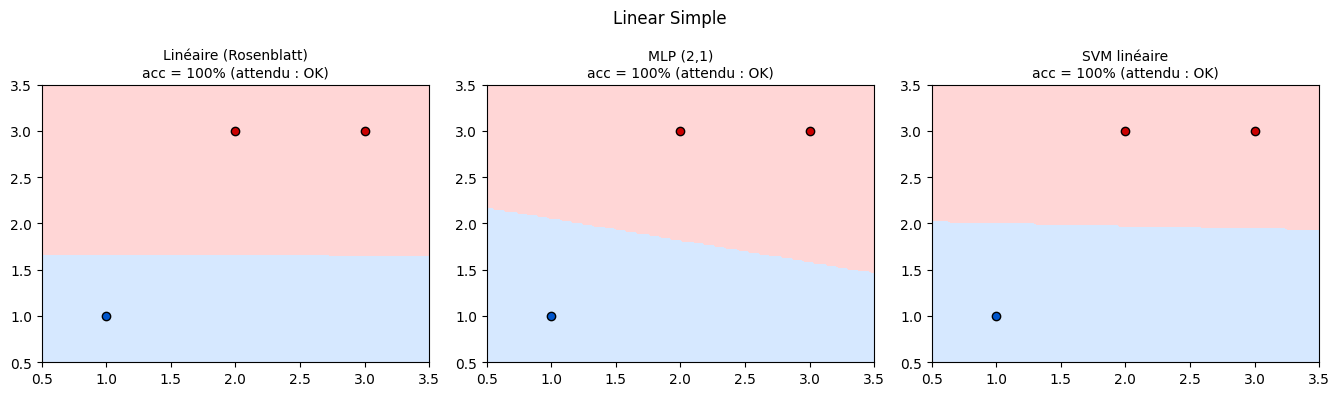

In [3]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
], dtype=float)
Y = np.array([1, -1, -1], dtype=float)

lin = ML_ESGI.LinearModel(2, is_classification=True)
lin.train(X.flatten().tolist(), Y.tolist(), 0.05, 500)

mlp = ML_ESGI.MLP([2, 1], True)
mlp.train(X.flatten().tolist(), Y.tolist(), 20000, 0.05)

svm = ML_ESGI.SVM(2, lambda_reg=0.001)
svm.train(X.tolist(), Y.tolist(), 0.01, 2000)

show_cas_2classes(X, Y, [
    ("Linéaire (Rosenblatt)", "OK", lin.predict),
    ("MLP (2,1)",             "OK", lambda x: 1.0 if mlp.predict(x)[0] >= 0 else -1.0),
    ("SVM linéaire",          "OK", svm.predict),
], "Linear Simple")

## Cas « Linear Multiple »
Attendus du cours : **Linear Model : OK** — **MLP (2, 1) : OK** *(+ SVM : OK)*

Training: [=================================================>] 99% 
Training: [===============>                Linear Multiple | Linéaire (Rosenblatt)        acc = 100%   (attendu : OK)
Training: [=================================================>] 99% 
Training: [==================================================] 100% 
  Linear Multiple | MLP (2,1)                    acc = 100%   (attendu : OK)
  Linear Multiple | SVM linéaire                 acc = 100%   (attendu : OK)


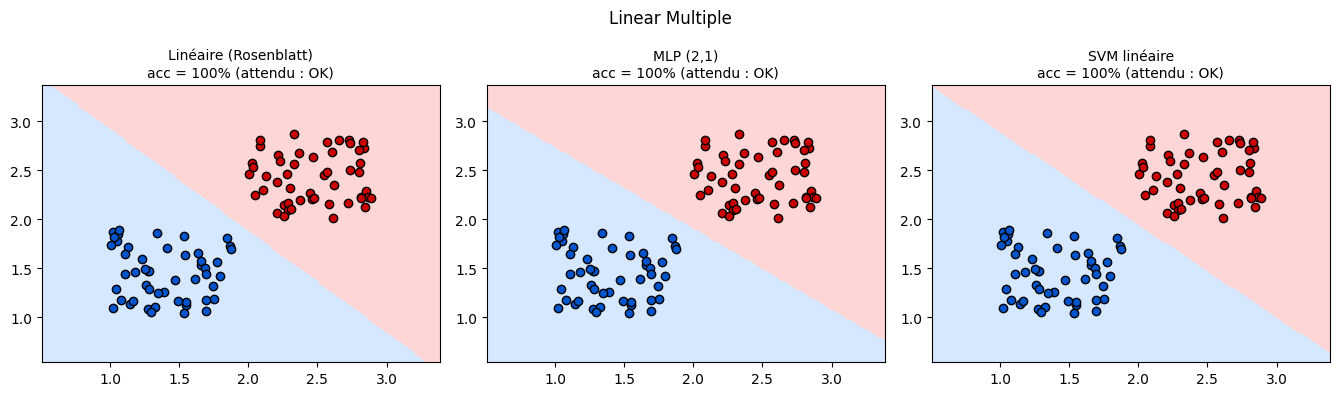

In [4]:
np.random.seed(42)
X = np.concatenate([np.random.random((50, 2)) * 0.9 + np.array([1, 1]),
                    np.random.random((50, 2)) * 0.9 + np.array([2, 2])])
Y = np.concatenate([np.ones((50, 1)), np.ones((50, 1)) * -1.0]).flatten()

lin = ML_ESGI.LinearModel(2, is_classification=True)
lin.train(X.flatten().tolist(), Y.tolist(), 0.01, 1000)

mlp = ML_ESGI.MLP([2, 1], True)
mlp.train(X.flatten().tolist(), Y.tolist(), 50000, 0.05)

svm = ML_ESGI.SVM(2, lambda_reg=0.001)
svm.train(X.tolist(), Y.tolist(), 0.01, 2000)

show_cas_2classes(X, Y, [
    ("Linéaire (Rosenblatt)", "OK", lin.predict),
    ("MLP (2,1)",             "OK", lambda x: 1.0 if mlp.predict(x)[0] >= 0 else -1.0),
    ("SVM linéaire",          "OK", svm.predict),
], "Linear Multiple")

## Cas « XOR »
Attendus du cours : **Linear Model : KO** — **MLP (2, 2, 1) : OK**
*(+ extensions : SVM linéaire : KO • SVM avec transformation (x, y, x·y) : OK • RBF 4 centres : OK)*

Le XOR n'est **pas linéairement séparable** : aucun hyperplan du plan (x, y) ne sépare les classes.
Deux issues vues en cours : ajouter une **transformation non linéaire des entrées** (le modèle reste
linéaire **en W**), ou utiliser un modèle intrinsèquement non linéaire (MLP, RBF).

Training: [=================================================>] 99% 
Training: [=================================================>] 99% 
Traini  XOR | Linéaire (Rosenblatt)        acc =  50%   (attendu : KO)
Training: [==================================================] 100% 
Training: [==================================================] 100% 
[RBF] Phase 1 : K-Means (4 centres)...
  [K-Means] Convergence à l'itération 2                        ] 0%

[RBF] Phase 2 : Calcul de la matrice Phi et moindres carrés (gamma=1)...
  [Phi] [=====================================>            ] 75%  XOR | MLP (2,2,1)                  acc = 100%   (attendu : OK)
  XOR | SVM linéaire                 acc =  25%   (attendu : KO)
  XOR | SVM + transfo (x,y,xy)       acc = 100%   (attendu : OK)
  XOR | RBF (4 centres)              acc = 100%   (attendu : OK)


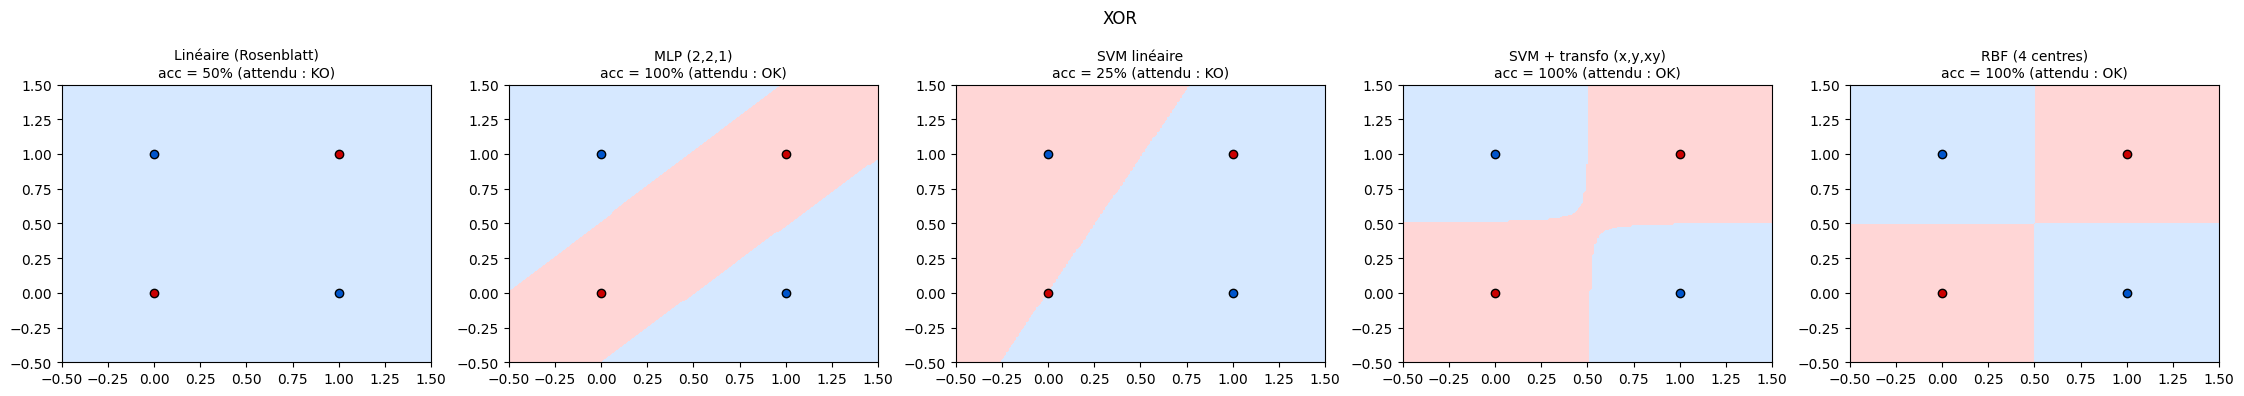

In [5]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]], dtype=float)
Y = np.array([1, 1, -1, -1], dtype=float)

lin = ML_ESGI.LinearModel(2, is_classification=True)
lin.train(X.flatten().tolist(), Y.tolist(), 0.1, 1000)

def train_mlp_xor():
    m = ML_ESGI.MLP([2, 2, 1], True)
    m.train(X.flatten().tolist(), Y.tolist(), 100000, 0.1)
    return m
mlp = meilleur_essai(train_mlp_xor,
                     lambda m: accuracy_binaire(lambda x: 1.0 if m.predict(x)[0] >= 0 else -1.0, X, Y),
                     seuil=1.0)

svm_lin = ML_ESGI.SVM(2, lambda_reg=0.001)
svm_lin.train(X.tolist(), Y.tolist(), 0.1, 5000)

# Transformation non linéaire explicite : (x, y) -> (x, y, x*y)
X_t = np.array([[a, b, a * b] for a, b in X])
svm_t = ML_ESGI.SVM(3, lambda_reg=0.001)
svm_t.train(X_t.tolist(), Y.tolist(), 0.1, 5000)

rbf = ML_ESGI.RBF(2, 4, 1, 1.0, True)   # 4 centres = 1 par point -> interpolation
rbf.train(X.flatten().tolist(), Y.tolist(), 4)

show_cas_2classes(X, Y, [
    ("Linéaire (Rosenblatt)", "KO", lin.predict),
    ("MLP (2,2,1)",           "OK", lambda x: 1.0 if mlp.predict(x)[0] >= 0 else -1.0),
    ("SVM linéaire",          "KO", svm_lin.predict),
    ("SVM + transfo (x,y,xy)","OK", lambda x: svm_t.predict([x[0], x[1], x[0] * x[1]])),
    ("RBF (4 centres)",       "OK", lambda x: rbf.predict(x)[0]),
], "XOR")

## Cas « Cross »
Attendus du cours : **Linear Model : KO** — **MLP (2, 4, 1) : OK** *(+ RBF : OK)*

  [Phi] [==================================================] 100%
[RBF] Entraînement terminé — MSE : 3.91793e-07 | Taux d'erreur : 0%
Training: [=================================================>] 99% 
Training: [=================================================>] 99% 
[RBF] Phase 1 : K-Means (40 centres)...
  [K-Means] [>                        Cross | Linéaire (Rosenblatt)        acc =  49%   (attendu : KO)
  [K-Means] Convergence à l'itération 14                       ] 4%

[RBF] Phase 2 : Calcul de la matrice Phi et moindres carrés (gamma=1)...
  [Phi] [============================================>     ] 89%  Cross | MLP (2,4,1)                  acc = 100%   (attendu : OK)
  Cross | RBF (40 centres)             acc =  95%   (attendu : OK)


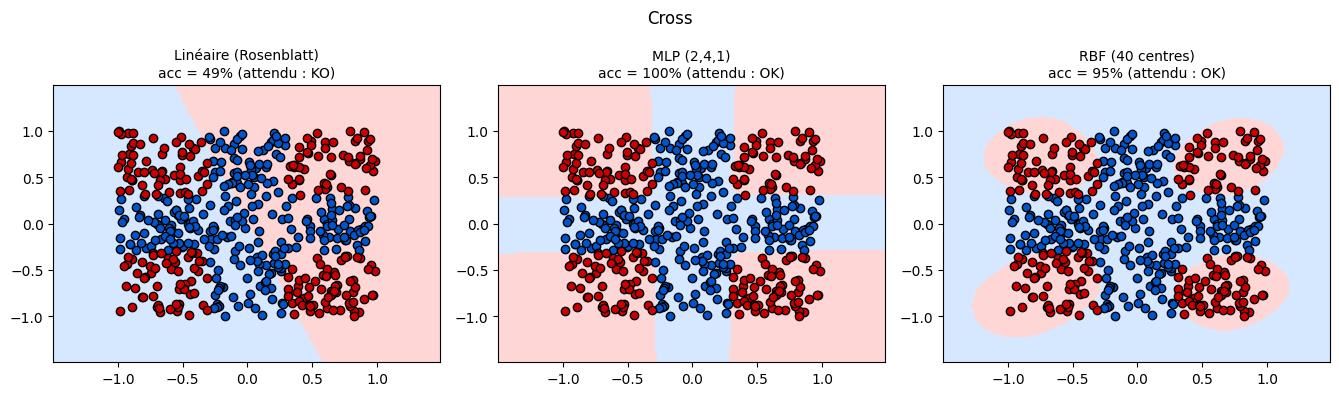

In [6]:
np.random.seed(7)
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X], dtype=float)

lin = ML_ESGI.LinearModel(2, is_classification=True)
lin.train(X.flatten().tolist(), Y.tolist(), 0.01, 1000)

def train_mlp_cross():
    m = ML_ESGI.MLP([2, 4, 1], True)
    m.train(X.flatten().tolist(), Y.tolist(), 500000, 0.05)
    return m
mlp = meilleur_essai(train_mlp_cross,
                     lambda m: accuracy_binaire(lambda x: 1.0 if m.predict(x)[0] >= 0 else -1.0, X, Y),
                     seuil=0.95, essais=4)

rbf = ML_ESGI.RBF(2, 40, 1, 1.0, True)
rbf.train(X.flatten().tolist(), Y.tolist(), 500)

show_cas_2classes(X, Y, [
    ("Linéaire (Rosenblatt)", "KO", lin.predict),
    ("MLP (2,4,1)",           "OK", lambda x: 1.0 if mlp.predict(x)[0] >= 0 else -1.0),
    ("RBF (40 centres)",      "OK", lambda x: rbf.predict(x)[0]),
], "Cross")

## Cas « Multi Linear 3 classes »
Attendus du cours : **Linear Model ×3 (One-vs-Rest) : OK** — **MLP (2, 3) : OK**

  [Phi] [==================================================] 100%
[RBF] Entraînement terminé — MSE : 0.244418 | Taux d'erreur : 4.6%
Training: [=================================================>] 99% 
Training: [=================================================>] 99% 
Training: [=========>                                        ] 18%  Multi Linear 3 classes | Linéaire ×3 (One-vs-Rest)    acc = 100%   (attendu : OK)
Training: [=================================================>] 99% 
Training: [============================  Multi Linear 3 classes | MLP (2,3)                    acc = 100%   (attendu : OK)
Training: [=================================================>] 99% 


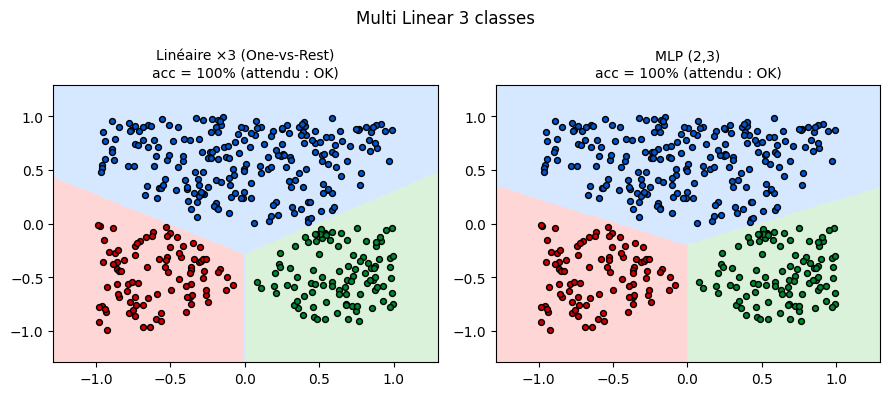

In [7]:
np.random.seed(11)
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [-1, -1, -1] for p in X])

# On ne garde que les points appartenant à une des 3 classes (comme dans le notebook du cours)
garde = [not np.all(ligne == [-1, -1, -1]) for ligne in Y]
X, Y = X[garde], Y[garde].astype(float)

pred_lin = entrainer_lineaire_ovr(X, Y, lr=0.05, epochs=2000)

mlp = ML_ESGI.MLP([2, 3], True)
mlp.train(X.flatten().tolist(), Y.flatten().tolist(), 100000, 0.05)

show_cas_multiclasses(X, Y, [
    ("Linéaire ×3 (One-vs-Rest)", "OK", pred_lin),
    ("MLP (2,3)",                 "OK", lambda x: int(np.argmax(mlp.predict(x)))),
], "Multi Linear 3 classes")

## Cas « Multi Cross »
Attendus du cours : **Linear Model ×3 : KO** — **MLP (2, ?, ?, 3) : OK** *(+ RBF : OK)*

Le motif est périodique (bandes tous les 0,5) : aucune combinaison de 3 séparations linéaires
ne peut le capturer → il faut de la **profondeur** (MLP) ou des **fonctions locales** (RBF).

> Hyperparamètres MLP : c'est le cas le plus dur de la batterie. Avec un learning rate de 0,1
> le SGD n'arrive jamais à sculpter des bandes de largeur 0,25 (~50-70 % d'accuracy) ; il faut
> un **pas plus fin (0,03) et beaucoup plus d'itérations (4 M)** → ~95 %. Illustration directe
> de l'« impact des paramètres sur la rapidité de convergence » que le syllabus demande d'étudier.

Training: [=================================================>] 99% 
Training: [=================================================>] 99% 
Training: [===============  Multi Cross | Linéaire ×3 (One-vs-Rest)    acc =  34%   (attendu : KO)
Training: [=================================================>] 99% 
Training: [=================================================>] 99% 
[RBF] Phase 1 : K-Means (100 centres)...
  [K-Means] [=>                                Multi Cross | MLP (2,32,32,3)              acc =  97%   (attendu : OK)
  [K-Means] Convergence à l'itération 13                       ] 3%

[RBF] Phase 2 : Calcul de la matrice Phi et moindres carrés (gamma=1)...
  [Phi] [============================================>     ] 89%  Multi Cross | RBF (100 centres)            acc =  53%   (attendu : OK)


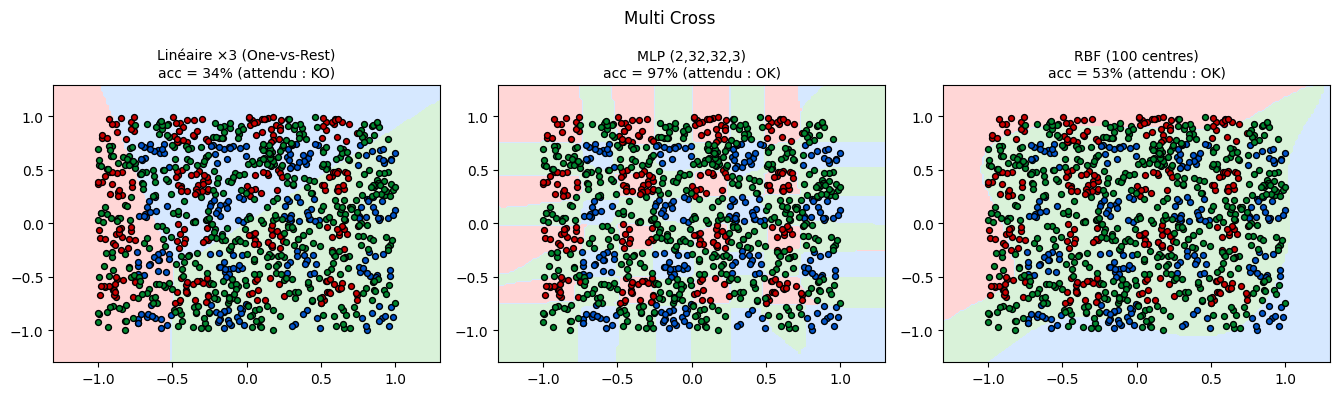

In [8]:
np.random.seed(5)
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else
              [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else
              [-1, -1, 1] for p in X], dtype=float)

pred_lin = entrainer_lineaire_ovr(X, Y, lr=0.05, epochs=1000)

def train_mlp_mcross():
    # lr 0.03 sans decay : validé à ~95 % (lr 0.1 plafonne à ~60 % sur ce motif fin)
    m = ML_ESGI.MLP([2, 32, 32, 3], True)
    m.train(X.flatten().tolist(), Y.flatten().tolist(), 4000000, 0.03)
    return m
mlp = meilleur_essai(train_mlp_mcross,
                     lambda m: accuracy_multi(lambda x: int(np.argmax(m.predict(x))), X, Y),
                     seuil=0.90, essais=2)

rbf = ML_ESGI.RBF(2, 100, 3, 1.0, True)
rbf.train(X.flatten().tolist(), Y.flatten().tolist(), 1000)

show_cas_multiclasses(X, Y, [
    ("Linéaire ×3 (One-vs-Rest)", "KO", pred_lin),
    ("MLP (2,32,32,3)",           "OK", lambda x: int(np.argmax(mlp.predict(x)))),
    ("RBF (100 centres)",         "OK", lambda x: int(np.argmax(rbf.predict_raw(x)))),
], "Multi Cross")

---
# 2. Régression

## Cas « Linear Simple 2D »
Attendus du cours : **Linear Model : OK** — **MLP (1, 1) : OK**

  [Phi] [==================================================] 100%
[RBF] Entraînement terminé — MSE : 0.750457 | Taux d'erreur : 47.2%
Training: [>                                                 ] 0%   Linear Simple 2D | Linéaire (desc. gradient)    MSE = 0.0000   (attendu : OK)
  Linear Simple 2D | MLP (1,1)                    MSE = 0.0000   (attendu : OK)
Training: [=================================================>] 99% 
Training: [=================================================>] 99% 


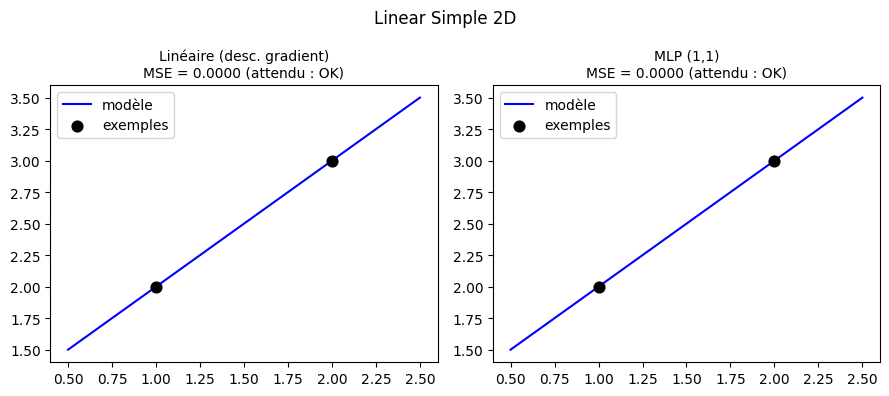

In [9]:
X = np.array([[1], [2]], dtype=float)
Y = np.array([2, 3], dtype=float)

lin = ML_ESGI.LinearModel(1, is_classification=False)
lin.train(X.flatten().tolist(), Y.tolist(), 0.05, 5000)

mlp = ML_ESGI.MLP([1, 1], False)
mlp.train(X.flatten().tolist(), Y.tolist(), 50000, 0.01)

show_regression_1d(X, Y, [
    ("Linéaire (desc. gradient)", "OK", lin.predict),
    ("MLP (1,1)",                 "OK", lambda x: mlp.predict(x)[0]),
], "Linear Simple 2D")

## Cas « Non Linear Simple 2D »
Attendus du cours : **Linear Model : OK** *(meilleure droite au sens des moindres carrés)* — **MLP (1, ?, 1) : OK** *(+ RBF : OK)*

Training: [>                                                 ] 0%   Non Linear Simple 2D | Linéaire (desc. gradient)    MSE = 0.1251   (attendu : OK)
  Non Linear Simple 2D | MLP (1,4,1)                  MSE = 0.0000   (attendu : OK)
  Non Linear Simple 2D | RBF (3 centres)              MSE = 0.0000   (attendu : OK)
Training: [=================================================>] 99% 
Training: [=================================================>] 99% 
[RBF] Phase 1 : K-Means (3 centres)...
  [K-Means] Convergence à l'itération 2                        ] 0%

[RBF] Phase 2 : Calcul de la matrice Phi et moindres carrés (gamma=1)...
  [Phi] [=================================>                ] 66%

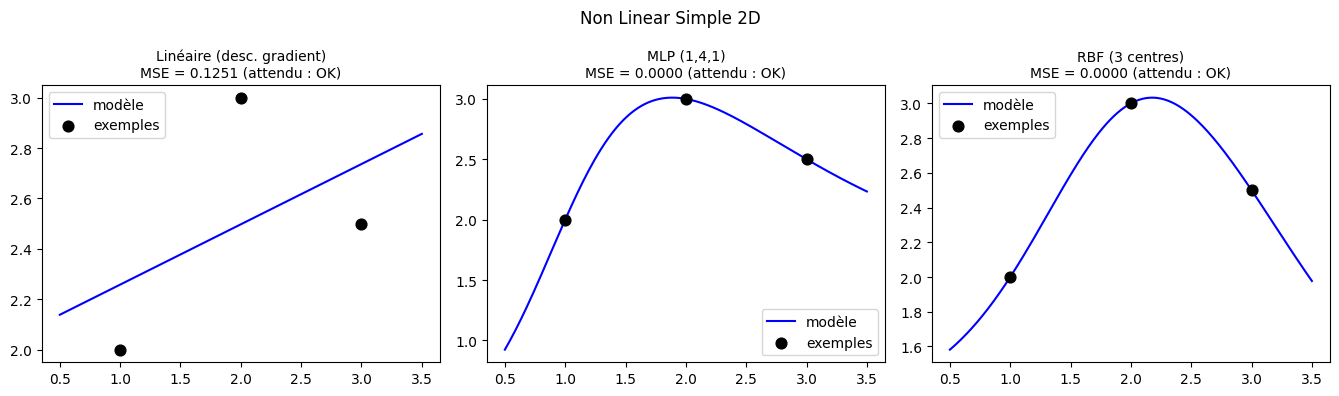

In [10]:
X = np.array([[1], [2], [3]], dtype=float)
Y = np.array([2, 3, 2.5], dtype=float)

lin = ML_ESGI.LinearModel(1, is_classification=False)
lin.train(X.flatten().tolist(), Y.tolist(), 0.02, 10000)

def train_mlp_nl2d():
    m = ML_ESGI.MLP([1, 4, 1], False)
    m.train(X.flatten().tolist(), Y.tolist(), 200000, 0.01)
    return m
mlp = meilleur_essai(train_mlp_nl2d, lambda m: -mse(lambda x: m.predict(x)[0], X, Y),
                     seuil=-0.01, essais=3)

rbf = ML_ESGI.RBF(1, 3, 1, 1.0, False)   # 1 centre par point -> interpolation quasi exacte
rbf.train(X.flatten().tolist(), Y.tolist(), 3)

show_regression_1d(X, Y, [
    ("Linéaire (desc. gradient)", "OK", lin.predict),
    ("MLP (1,4,1)",               "OK", lambda x: mlp.predict(x)[0]),
    ("RBF (3 centres)",           "OK", lambda x: rbf.predict(x)[0]),
], "Non Linear Simple 2D")

## Cas « Linear Simple 3D »
Attendus du cours : **Linear Model : OK** — **MLP (2, 1) : OK**

  [Phi] [==================================================] 100%
[RBF] Entraînement terminé — MSE : 7.47588e-09
Training: [=============  Linear Simple 3D | Linéaire (desc. gradient)    MSE = 0.0000   (attendu : OK)
  Linear Simple 3D | MLP (2,1)                    MSE = 0.0000   (attendu : OK)
Training: [=================================================>] 99% 
Training: [=================================================>] 99% 


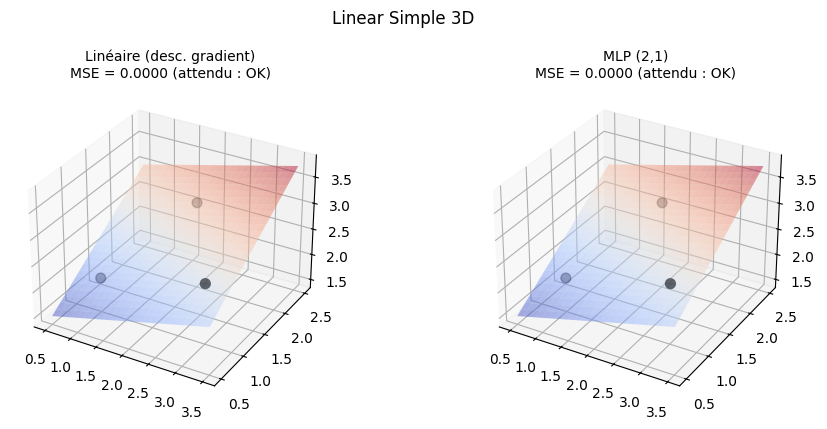

In [11]:
X = np.array([[1, 1], [2, 2], [3, 1]], dtype=float)
Y = np.array([2, 3, 2.5], dtype=float)

lin = ML_ESGI.LinearModel(2, is_classification=False)
lin.train(X.flatten().tolist(), Y.tolist(), 0.02, 20000)

mlp = ML_ESGI.MLP([2, 1], False)
mlp.train(X.flatten().tolist(), Y.tolist(), 100000, 0.01)

show_regression_2d(X, Y, [
    ("Linéaire (desc. gradient)", "OK", lin.predict),
    ("MLP (2,1)",                 "OK", lambda x: mlp.predict(x)[0]),
], "Linear Simple 3D")

## Cas « Linear Tricky 3D »
Attendus du cours : **Linear Model : OK** — **MLP (2, 1) : OK**

Piège du cas : les entrées sont **colinéaires** (toutes sur la droite x = y) → il existe une
**infinité de plans solutions**. La descente de gradient converge vers l'un d'eux. (La pseudo-inverse
du cours demanderait ici des précautions : la matrice XᵀX est singulière.)

Training: [=======>                                       Linear Tricky 3D | Linéaire (desc. gradient)    MSE = 0.0000   (attendu : OK)
  Linear Tricky 3D | MLP (2,1)                    MSE = 0.0000   (attendu : OK)
Training: [=================================================>] 99% 
Training: [=================================================>] 99% 


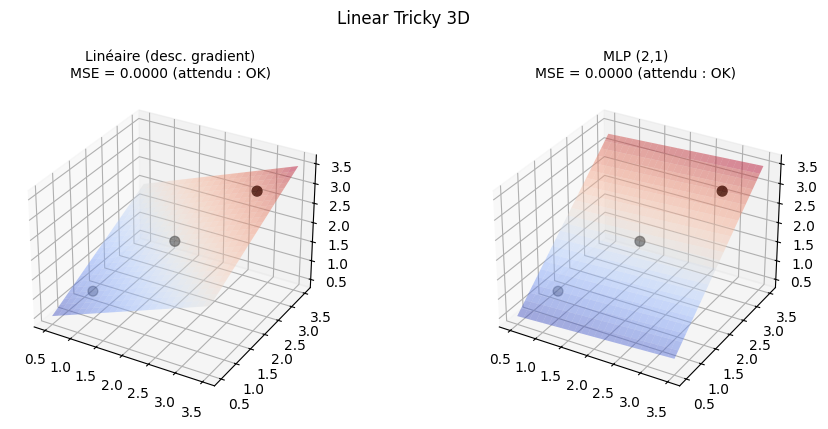

In [12]:
X = np.array([[1, 1], [2, 2], [3, 3]], dtype=float)
Y = np.array([1, 2, 3], dtype=float)

lin = ML_ESGI.LinearModel(2, is_classification=False)
lin.train(X.flatten().tolist(), Y.tolist(), 0.01, 20000)

mlp = ML_ESGI.MLP([2, 1], False)
mlp.train(X.flatten().tolist(), Y.tolist(), 100000, 0.01)

show_regression_2d(X, Y, [
    ("Linéaire (desc. gradient)", "OK", lin.predict),
    ("MLP (2,1)",                 "OK", lambda x: mlp.predict(x)[0]),
], "Linear Tricky 3D")

## Cas « Non Linear Simple 3D »
Attendus du cours : **Linear Model : KO** — **MLP (2, 2, 1) : OK** *(+ RBF : OK)*

C'est le « XOR de la régression » : aucun plan ne passe près des 4 points → le modèle linéaire
ne peut pas faire mieux qu'un compromis, le MLP (activations tanh) et le RBF (gaussiennes) si.

Training: [=====  Non Linear Simple 3D | Linéaire (desc. gradient)    MSE = 2.2502   (attendu : KO)
Training: [=============  Non Linear Simple 3D | MLP (2,2,1)                  MSE = 0.0000   (attendu : OK)
Training: [=================================================>] 99% 
Traini  Non Linear Simple 3D | RBF (4 centres)              MSE = 0.0000   (attendu : OK)
Training: [=================================================>] 99% 
[RBF] Phase 1 : K-Means (4 centres)...
  [K-Means] Convergence à l'itération 2                        ] 0%

[RBF] Phase 2 : Calcul de la matrice Phi et moindres carrés (gamma=1)...
  [Phi] [=====================================>            ] 75%

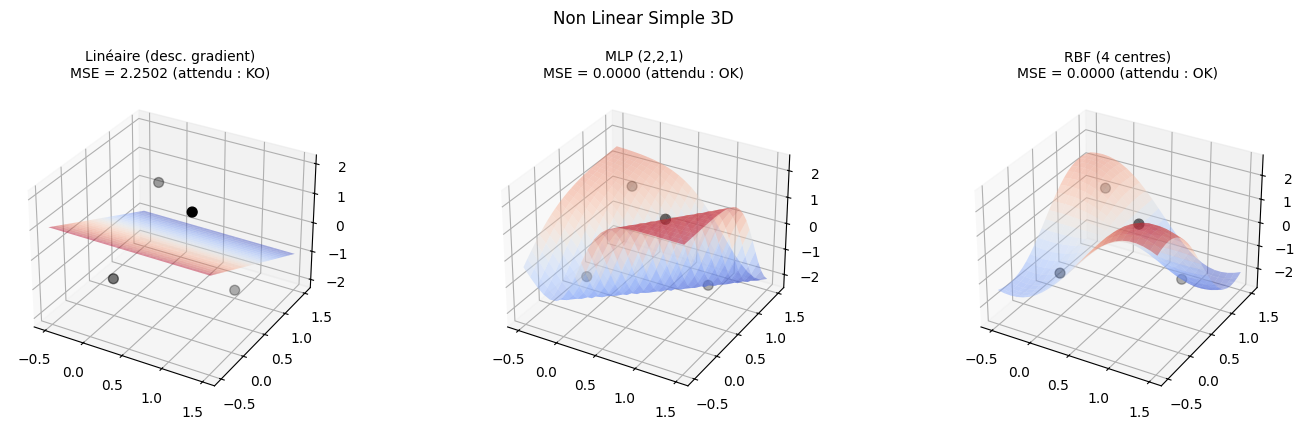

In [13]:
X = np.array([[1, 0], [0, 1], [1, 1], [0, 0]], dtype=float)
Y = np.array([2, 1, -2, -1], dtype=float)

lin = ML_ESGI.LinearModel(2, is_classification=False)
lin.train(X.flatten().tolist(), Y.tolist(), 0.02, 20000)

def train_mlp_nl3d():
    m = ML_ESGI.MLP([2, 2, 1], False)
    m.train(X.flatten().tolist(), Y.tolist(), 300000, 0.01)
    return m
mlp = meilleur_essai(train_mlp_nl3d, lambda m: -mse(lambda x: m.predict(x)[0], X, Y),
                     seuil=-0.05, essais=4)

rbf = ML_ESGI.RBF(2, 4, 1, 1.0, False)
rbf.train(X.flatten().tolist(), Y.tolist(), 4)

show_regression_2d(X, Y, [
    ("Linéaire (desc. gradient)", "KO", lin.predict),
    ("MLP (2,2,1)",               "OK", lambda x: mlp.predict(x)[0]),
    ("RBF (4 centres)",           "OK", lambda x: rbf.predict(x)[0]),
], "Non Linear Simple 3D")

---
# Bilan

| Cas | Linéaire | MLP | SVM | RBF |
|---|---|---|---|---|
| Linear Simple | ✅ OK | ✅ OK | ✅ OK | — |
| Linear Multiple | ✅ OK | ✅ OK | ✅ OK | — |
| XOR | ❌ KO (attendu) | ✅ OK | ❌ KO / ✅ OK avec transfo | ✅ OK |
| Cross | ❌ KO (attendu) | ✅ OK | — | ✅ OK |
| Multi Linear 3 classes | ✅ OK | ✅ OK | — | — |
| Multi Cross | ❌ KO (attendu) | ✅ OK | — | ✅ OK |
| Linear Simple 2D (rég.) | ✅ OK | ✅ OK | — | — |
| Non Linear Simple 2D (rég.) | ✅ OK (droite MC) | ✅ OK | — | ✅ OK |
| Linear Simple 3D (rég.) | ✅ OK | ✅ OK | — | — |
| Linear Tricky 3D (rég.) | ✅ OK | ✅ OK | — | — |
| Non Linear Simple 3D (rég.) | ❌ KO (attendu) | ✅ OK | — | ✅ OK |

**Lecture théorique** (cf. slides du cours) : le modèle linéaire est linéaire **en W**, pas en X —
d'où la puissance des transformations non linéaires des entrées. Quand la géométrie du problème
n'est pas connue à l'avance, on délègue cette transformation au modèle : couches cachées du MLP
(théorème d'approximation universelle) ou base de gaussiennes locales du RBF. Les échecs « KO »
ci-dessus ne sont pas des bugs : ils **démontrent** la limite d'expressivité de chaque modèle,
exactement comme annoncé dans le cours.